# Perfiles analíticos de densidad

Este notebook utiliza `dm_spikes.power_law_profile` y `dm_spikes.pseudo_isothermal_sphere` como fuentes de las expresiones físicas. Superpone los perfiles cuspidados exactos para $0.01\leq\gamma\leq1.99$ y el perfil isotérmico analítico.

In [36]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import numpy as np

src_path = Path.cwd() / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from dm_spikes import schwarzschild_radius
import dm_spikes.power_law_profile as power_law
import dm_spikes.pseudo_isothermal_sphere as pseudo_isothermal

In [37]:
M = 2.6e6  # Msun
r0 = power_law.D  # pc
rho0_iso = 0.0062  # Msun pc^-3
sigma_v = 100.0  # km s^-1

R_S = schwarzschild_radius(M)
r_iso_match = pseudo_isothermal.isothermal_matching_radius(M, sigma_v)
gamma_values = np.arange(0.01, 2.00, 0.01)

print(f"R_S = {R_S:.6e} pc")
print(f"Radio de empalme isotérmico = {r_iso_match:.6e} pc")
print(f"Número de perfiles cuspidados = {gamma_values.size}")

R_S = 2.488412e-07 pc
Radio de empalme isotérmico = 9.249315e-01 pc
Número de perfiles cuspidados = 199


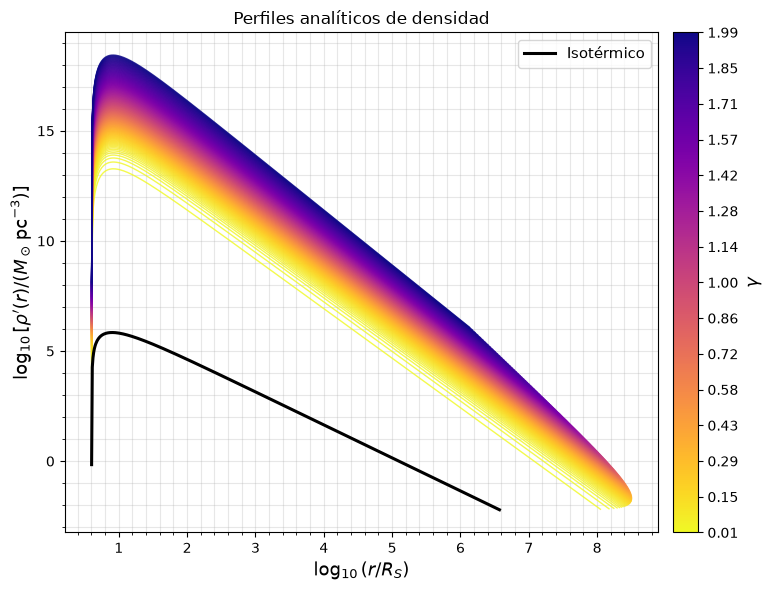

In [38]:
fig, ax = plt.subplots(figsize=(8, 6))

norm = Normalize(vmin=gamma_values.min(), vmax=gamma_values.max())
cmap = plt.get_cmap("plasma_r")
inner_radius = 4.0001 * R_S
radial_points = 600

for gamma in gamma_values:
    rho0_cusp = power_law.rho_D(gamma)
    R_sp = power_law.spike_radius(M, gamma, rho0_cusp, r0)
    r_cusp = np.geomspace(inner_radius, R_sp, radial_points)
    rho_cusp = power_law.cusp_profile(
        r_cusp,
        M,
        gamma,
        R_S,
        r0=r0,
        rho0=rho0_cusp,
    )
    valid = np.isfinite(rho_cusp) & (rho_cusp > 0.0)
    ax.plot(
        np.log10(r_cusp[valid] / R_S),
        np.log10(rho_cusp[valid]),
        color=cmap(norm(gamma)),
        lw=1.0,
        alpha=0.8,
    )

r_iso = np.geomspace(inner_radius, r_iso_match, radial_points)
rho_iso = pseudo_isothermal.isothermal_profile(
    r_iso, M, sigma_v, rho0_iso, R_S
)
valid_iso = np.isfinite(rho_iso) & (rho_iso > 0.0)
ax.plot(
    np.log10(r_iso[valid_iso] / R_S),
    np.log10(rho_iso[valid_iso]),
    color="black",
    lw=2.2,
    label="Isotérmico",
    zorder=5,
)

colorbar_source = ScalarMappable(norm=norm, cmap=cmap)
colorbar_source.set_array([])
colorbar = fig.colorbar(colorbar_source, ax=ax, pad=0.02)
colorbar.set_label(r"$\gamma$", fontsize=13)
gamma_ticks = np.linspace(gamma_values.min(), gamma_values.max(), 15)
colorbar.set_ticks(gamma_ticks)
colorbar.set_ticklabels([f"{gamma:.2f}" for gamma in gamma_ticks])

ax.set_xlabel(r"$\log_{10}(r/R_S)$", fontsize=13)
ax.set_ylabel(
    r"$\log_{10}[\rho'(r)/(M_\odot\,\mathrm{pc}^{-3})]$",
    fontsize=13,
)
ax.set_title("Perfiles analíticos de densidad")
ax.grid(True, which="both", alpha=0.3)
ax.minorticks_on()
ax.legend(loc="best", fontsize=11)

fig.tight_layout()
plt.show()

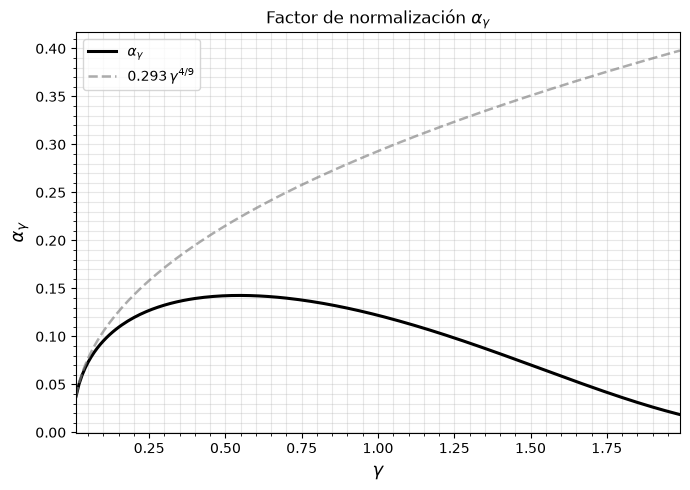

In [39]:
alpha_exact = power_law.alpha_gamma(gamma_values)
alpha_approx = 0.293 * gamma_values ** (4.0 / 9.0)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(
    gamma_values,
    alpha_exact,
    color="black",
    lw=2.2,
    label=r"$\alpha_\gamma$",
)
ax.plot(
    gamma_values,
    alpha_approx,
    color="gray",
    lw=1.8,
    ls="--",
    alpha=0.65,
    label=r"$0.293\,\gamma^{4/9}$",
)

ax.set_xlim(gamma_values.min(), gamma_values.max())
ax.set_xlabel(r"$\gamma$", fontsize=13)
ax.set_ylabel(r"$\alpha_\gamma$", fontsize=13)
ax.set_title(r"Factor de normalización $\alpha_\gamma$")
ax.grid(True, which="both", alpha=0.3)
ax.minorticks_on()
ax.legend(loc="best", fontsize=10)

fig.tight_layout()
plt.show()

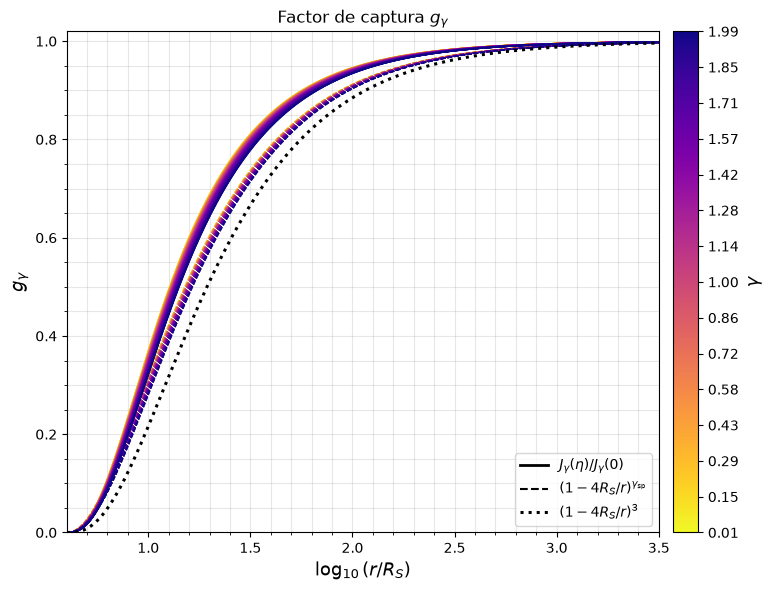

In [40]:
from matplotlib.lines import Line2D

x_capture = np.linspace(np.log10(4.0001), 5.0, 500)
r_capture = R_S * np.power(10.0, x_capture)
eta_capture = 4.0 * R_S / r_capture
capture_base = 1.0 - eta_capture

norm_capture = Normalize(
    vmin=gamma_values.min(), vmax=gamma_values.max()
)
cmap_capture = plt.get_cmap("plasma_r")

fig, ax = plt.subplots(figsize=(8, 6))

for gamma in gamma_values:
    color = cmap_capture(norm_capture(gamma))
    g_exact = power_law.g_gamma(eta_capture, gamma)
    gamma_sp = power_law.gamma_spike(gamma)
    g_spike_power = np.power(capture_base, gamma_sp)

    ax.plot(
        x_capture,
        g_exact,
        color=color,
        lw=1.0,
        alpha=0.8,
    )
    ax.plot(
        x_capture,
        g_spike_power,
        color=color,
        lw=0.9,
        ls="--",
        alpha=0.35,
    )

g_gondolo_silk = np.power(capture_base, 3.0)
ax.plot(
    x_capture,
    g_gondolo_silk,
    color="black",
    lw=2.2,
    ls=":",
    zorder=5,
)

colorbar_source = ScalarMappable(norm=norm_capture, cmap=cmap_capture)
colorbar_source.set_array([])
colorbar = fig.colorbar(colorbar_source, ax=ax, pad=0.02)
colorbar.set_label(r"$\gamma$", fontsize=13)
gamma_ticks = np.linspace(gamma_values.min(), gamma_values.max(), 15)
colorbar.set_ticks(gamma_ticks)
colorbar.set_ticklabels([f"{gamma:.2f}" for gamma in gamma_ticks])

legend_handles = [
    Line2D([], [], color="black", lw=2.0, ls="-",
           label=r"$J_\gamma(\eta)/J_\gamma(0)$"),
    Line2D([], [], color="black", lw=1.5, ls="--",
           label=r"$(1-4R_S/r)^{\gamma_{\rm sp}}$"),
    Line2D([], [], color="black", lw=2.2, ls=":",
           label=r"$(1-4R_S/r)^3$"),
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=10)

ax.set_xlim(np.log10(4.0001), 3.5)
ax.set_ylim(0.0, 1.02)
ax.set_xlabel(r"$\log_{10}(r/R_S)$", fontsize=13)
ax.set_ylabel(r"$g_\gamma$", fontsize=13)
ax.set_title(r"Factor de captura $g_\gamma$")
ax.grid(True, which="both", alpha=0.3)
ax.minorticks_on()

fig.tight_layout()
plt.show()

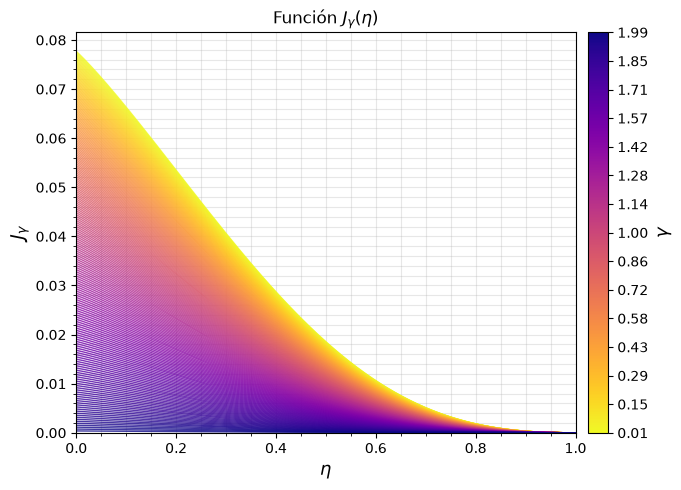

In [41]:
eta_values = np.linspace(0.0, 1.0, 400)
norm_J = Normalize(vmin=gamma_values.min(), vmax=gamma_values.max())
cmap_J = plt.get_cmap("plasma_r")

fig, ax = plt.subplots(figsize=(7, 5))

for gamma in gamma_values:
    J_values = power_law.J_gamma(eta_values, gamma)
    ax.plot(
        eta_values,
        J_values,
        color=cmap_J(norm_J(gamma)),
        lw=1.0,
        alpha=0.8,
    )

colorbar_source = ScalarMappable(norm=norm_J, cmap=cmap_J)
colorbar_source.set_array([])
colorbar = fig.colorbar(colorbar_source, ax=ax, pad=0.02)
colorbar.set_label(r"$\gamma$", fontsize=13)
gamma_ticks = np.linspace(gamma_values.min(), gamma_values.max(), 15)
colorbar.set_ticks(gamma_ticks)
colorbar.set_ticklabels([f"{gamma:.2f}" for gamma in gamma_ticks])

ax.set_xlim(0.0, 1.0)
ax.set_ylim(bottom=0.0)
ax.set_xlabel(r"$\eta$", fontsize=13)
ax.set_ylabel(r"$J_\gamma$", fontsize=13)
ax.set_title(r"Función $J_\gamma(\eta)$")
ax.grid(True, which="both", alpha=0.3)
ax.minorticks_on()

fig.tight_layout()
plt.show()

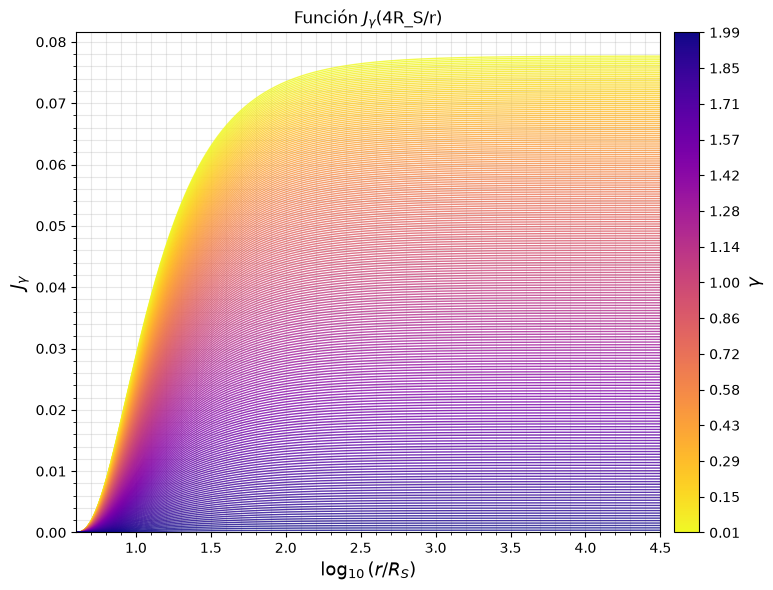

In [42]:
x_J_radius = np.linspace(np.log10(4.0001), 4.5, 500)
r_J = R_S * np.power(10.0, x_J_radius)
eta_J_radius = 4.0 * R_S / r_J
norm_J_radius = Normalize(
    vmin=gamma_values.min(), vmax=gamma_values.max()
)
cmap_J_radius = plt.get_cmap("plasma_r")

fig, ax = plt.subplots(figsize=(8, 6))

for gamma in gamma_values:
    J_radius = power_law.J_gamma(eta_J_radius, gamma)
    ax.plot(
        x_J_radius,
        J_radius,
        color=cmap_J_radius(norm_J_radius(gamma)),
        lw=1.0,
        alpha=0.8,
    )

colorbar_source = ScalarMappable(
    norm=norm_J_radius, cmap=cmap_J_radius
)
colorbar_source.set_array([])
colorbar = fig.colorbar(colorbar_source, ax=ax, pad=0.02)
colorbar.set_label(r"$\gamma$", fontsize=13)
gamma_ticks = np.linspace(gamma_values.min(), gamma_values.max(), 15)
colorbar.set_ticks(gamma_ticks)
colorbar.set_ticklabels([f"{gamma:.2f}" for gamma in gamma_ticks])

ax.set_xlim(np.log10(4.0001), 4.5)
ax.set_ylim(bottom=0.0)
ax.set_xlabel(r"$\log_{10}(r/R_S)$", fontsize=13)
ax.set_ylabel(r"$J_\gamma$", fontsize=13)
ax.set_title(r"Función $J_\gamma$(4R_S/r)")
ax.grid(True, which="both", alpha=0.3)
ax.minorticks_on()

fig.tight_layout()
plt.show()